## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Kamal Sangam

**Date:** Oct 2 2026

## Q1

**1. Difference between regression and classification**  
Regression predicts a numerical value, such as a house price. Classification predicts a category, such as the type of land mine. The main difference is the type of outcome being predicted.

**2. Confusion table**  
A confusion table compares the actual class with the class predicted by the model. It shows which predictions are correct and which classes are being confused with each other. This is useful because overall accuracy does not show which specific classes cause the most errors.

**3. SSE**  
SSE, or sum of squared errors, measures how far a model's predictions are from the actual values. It adds up the squared prediction errors. A smaller SSE means the predictions are closer to the actual values overall, while large errors have more influence because they are squared.

**4. Overfitting and underfitting**  
Overfitting happens when a model is too closely fitted to the training data and does not generalize well to new data. Underfitting happens when a model is too simple and misses important patterns in the data. A good model should perform well on new data, not just the training data.

**5. Training and testing data**  
A separate test set gives us data that the model did not use when it was trained. This gives a better idea of how the model will perform on new observations. However, we should not repeatedly choose $k$ using the final test set because that would make the test set part of the tuning process. It is better to choose $k$ using a validation set and then use the test set only for the final evaluation.

**6. Class labels vs. probability distributions**  
A class-label prediction is simple because it gives one clear answer. However, it does not tell us how confident the model is. A probability distribution gives the estimated probability for each class, so it gives more information about uncertainty. The weakness is that probabilities are more complicated to interpret and may not always be well calibrated.


## Q2

Data shape: (338, 4)

First five rows:


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1



Summary statistics:


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000



Mine type counts:


mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


Missing values:


voltage      0
height       0
soil         0
mine_type    0
dtype: int64


Feature means by mine type:


,voltage,height,soil
mine_type,,,
1,0.296463,0.495519,0.492958
2,0.721123,0.487013,0.508571
3,0.402408,0.527548,0.496970
4,0.345365,0.506887,0.503030
5,0.379598,0.530070,0.516923


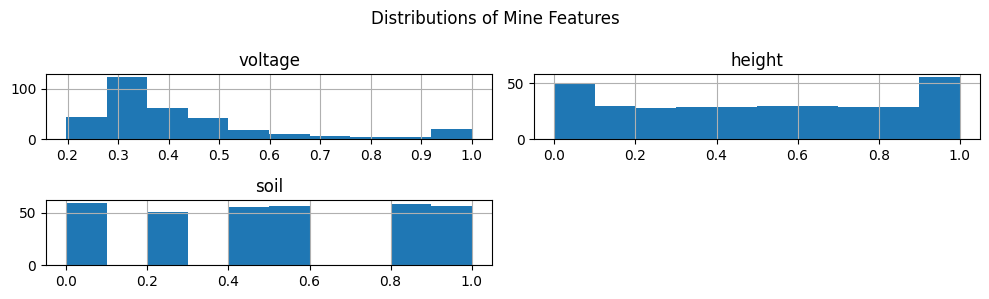

In [2]:
# Q2.1 Load the data and perform EDA

import pandas as pd
import matplotlib.pyplot as plt

# Load the data
land_mines = pd.read_csv("data/land_mines.csv")

print("Data shape:", land_mines.shape)
print("\nFirst five rows:")
display(land_mines.head())

print("\nSummary statistics:")
display(land_mines.describe())

print("\nMine type counts:")
display(land_mines["mine_type"].value_counts().sort_index())

print("\nMissing values:")
display(land_mines.isna().sum())

print("\nFeature means by mine type:")
display(land_mines.groupby("mine_type")[["voltage", "height", "soil"]].mean())

# Simple plots to see the distributions of the features
land_mines[["voltage", "height", "soil"]].hist(bins=10, figsize=(10, 3))
plt.suptitle("Distributions of Mine Features")
plt.tight_layout()
plt.show()


In [ ]:
#%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 2.1 MB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 2.1 MB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Q2.3 Split the data 50/50

from sklearn.model_selection import train_test_split

# Separate the features from the target
X = land_mines[["voltage", "height", "soil"]]
y = land_mines["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


Training rows: 169
Test rows: 169


Best k: 2
Best validation accuracy: 0.465


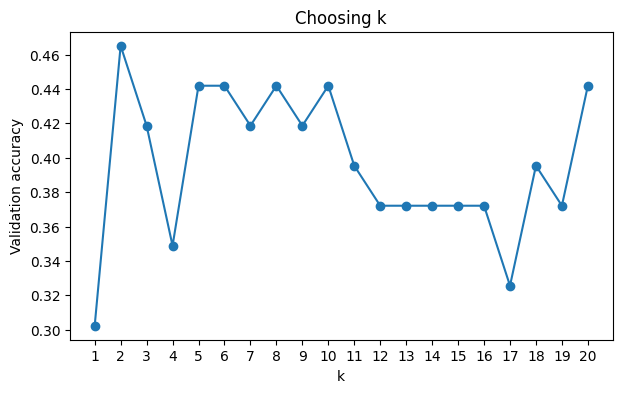

Confusion table: rows = actual, columns = predicted


,1,2,3,4,5
1,26,0,6,3,1
2,0,32,0,3,0
3,12,1,10,6,4
4,9,6,10,8,0
5,11,0,12,8,1


Test accuracy: 0.456

Accuracy by actual mine type:
Mine type 1 : 0.722
Mine type 2 : 0.914
Mine type 3 : 0.303
Mine type 4 : 0.242
Mine type 5 : 0.031


In [10]:
# Q2.4-Q2.8 Build the k-NN model and evaluate it

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# k-NN uses distances, so put all features on the same 0-to-1 scale
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use part of the training data to choose k
X_fit, X_validate, y_fit, y_validate = train_test_split(
    X_train_scaled, y_train, test_size=0.25, random_state=42, stratify=y_train
)

# Try several values of k and compare their validation accuracy
k_values = range(1, 21)
validation_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_fit, y_fit)
    predictions = model.predict(X_validate)
    accuracy = accuracy_score(y_validate, predictions)
    validation_accuracies.append(accuracy)

best_k = list(k_values)[validation_accuracies.index(max(validation_accuracies))]

print("Best k:", best_k)
print("Best validation accuracy:", round(max(validation_accuracies), 3))

# Plot validation accuracy for the different k values
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), validation_accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("Validation accuracy")
plt.title("Choosing k")
plt.xticks(list(k_values))
plt.show()

# Train the final model on all of the training data
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)

# Predict the test data
y_pred = model.predict(X_test_scaled)

# Q2.6 Confusion table
labels = [1, 2, 3, 4, 5]
confusion = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion table: rows = actual, columns = predicted")
display(pd.DataFrame(confusion, index=labels, columns=labels))

# Q2.7 Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", round(accuracy, 3))

# Calculate accuracy for each actual mine type
print("\nAccuracy by actual mine type:")
for mine_type in labels:
    correct = confusion[mine_type - 1, mine_type - 1]
    total = confusion[mine_type - 1].sum()
    print("Mine type", mine_type, ":", round(correct / total, 3))


## Q2.5-Q2.8 Explanation

**How $k$ was selected:** I used part of the training data as a validation set and tried values of $k$ from 1 through 20. I selected the value with the highest validation accuracy. The final test set was not used to choose $k$.

**Confusion table:** The rows show the actual mine type and the columns show the predicted mine type. The diagonal contains correct predictions. Values away from the diagonal are classification errors.

**Accuracy:** The overall test accuracy is shown above. The class by class accuracies show that the model does not perform equally well for every mine type. Some types are easier to identify, while others are frequently confused with another type.

**Practical advice:** Because this is a safety critical problem, I would not use this model by itself to decide that a mine is safe or to make a final mine clearance decision. The model could be used as a screening or decision-support tool, but its predictions should be checked by trained experts and established mine clearance procedures.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 0ca969143c135ba3d1421bb3124a3bdb9b81eb5c
- **AI tool and model used:** GPT-5.6 Luna

### *Prompts used

1. I have completed Phase 1 of this lab. I am giving you my entire notebook, including my written answers and Python code. Please review the entire notebook against the lab instructions and rubric. Identify any errors, missing requirements, incorrect reasoning, or areas where the code could be improved. Please explain each suggested change and keep any code suggestions simple and consistent with the Python and machine learning methods used in the course slides.

2. Please take another look at the completed notebook, especially the k-NN land mines analysis. Check whether my data exploration, train/test split, feature scaling, choice of k, model evaluation, confusion matrix, and discussion of the results are all appropriate. Point out anything that should be corrected or improved, but keep the code beginner-friendly and avoid unnecessarily complicated solutions.

3. Now review the notebook from the perspective of a student submitting this lab. Are there any changes you would recommend to improve the clarity or presentation of the notebook in addition to the technical corrections?

### *AI-proposed changes


1. Keep the Q1 answers concise and directly connected to the rubric.
2. Use `MinMaxScaler` before k-NN because the model uses feature distances.
3. Follow the simple create → fit → predict k-NN workflow shown in the slides.
4. Choose `k` using a validation set instead of repeatedly checking the final test set.
5. Replace the confusion table with a color-coded heatmap.
6. Add custom colors and extra styling to the feature plots.
7. Add decorative headings, borders, and extra formatting around the results.
8. Report class-by-class accuracy and discuss the model's error patterns.

### *Evaluation of AI suggestions


| AI-proposed change | Decision | Reason and verification |
|---|---|---|
| 1. Keep the Q1 answers concise and directly connected to the rubric. | Accept | The answers stay focused on the concepts the questions ask about. |
| 2. Use `MinMaxScaler` before k-NN. | Accept | k-NN uses distances, so putting the features on the same 0-to-1 scale is useful and follows the slides. |
| 3. Keep the create → fit → predict k-NN workflow from the slides. | Accept | This makes the code easier to follow and matches the basic scikit-learn workflow shown in class. |
| 4. Choose `k` using validation accuracy instead of repeatedly checking the final test set. | Accept | The test set stays separate until the final evaluation. |
| 5. Replace the confusion table with a color-coded heatmap. | **Reject** | This is mostly cosmetic. The table already shows actual and predicted classes clearly, so the heatmap would not add much to the analysis. |
| 6. Add custom colors and extra styling to the feature plots. | **Reject** | The styling would change the appearance but would not change what we learn from the data. |
| 7. Add decorative headings, borders, and extra formatting around the results. | **Reject** | This would make the notebook more decorative but would not improve the model or its interpretation. |
| 8. Report class-by-class accuracy and discuss the error patterns. | Accept | This directly helps answer Q2.7 and Q2.8 because overall accuracy alone does not show which mine types are harder to classify. |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### Revised Q1

#### 1.1 Difference between regression and classification

Regression predicts a numerical outcome, while classification predicts a category or class. For example, predicting a house price is regression, while predicting whether an observation belongs to a particular mine type is classification.

#### 2.1 Confusion table

A confusion table compares the actual class with the class predicted by the model. It shows which predictions were correct and which classes were confused with one another. This gives more detail than accuracy alone because it shows where the model is making its mistakes.

#### 3.1 What SSE quantifies about a model

SSE, or sum of squared errors, measures the total squared difference between a model's predictions and the actual values. A smaller SSE means the predictions are closer to the observed values overall. Because the errors are squared, larger errors have a greater effect on the total.

#### 4.1 Overfitting and underfitting

Overfitting occurs when a model fits the training data too closely and does not perform as well on new data. Underfitting occurs when a model is too simple to capture important patterns in the data. A good model should generalize well rather than only performing well on its training data.

#### 5.1 Training and testing data

Splitting the data into training and test sets lets us evaluate the model on data it did not use during training. This gives a better estimate of how the model will perform on new observations. The test set should not be repeatedly used to choose the model or tune its parameters. Instead, a validation set can be used for tuning, while the test set is saved for the final evaluation.

#### 6.1 Class labels vs. probability distributions

A class-label prediction gives one predicted category, which makes it simple to interpret. However, it does not show how confident the model is. A probability distribution gives the estimated probability of each possible class, providing more information about uncertainty. The tradeoff is that probability predictions can be more complicated to interpret.

## Revised Q2:

Data shape: (338, 4)

First five rows:


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1



Summary statistics:


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000



Mine type counts:


mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


Missing values:


voltage      0
height       0
soil         0
mine_type    0
dtype: int64


Feature means by mine type:


,voltage,height,soil
mine_type,,,
1,0.296463,0.495519,0.492958
2,0.721123,0.487013,0.508571
3,0.402408,0.527548,0.496970
4,0.345365,0.506887,0.503030
5,0.379598,0.530070,0.516923


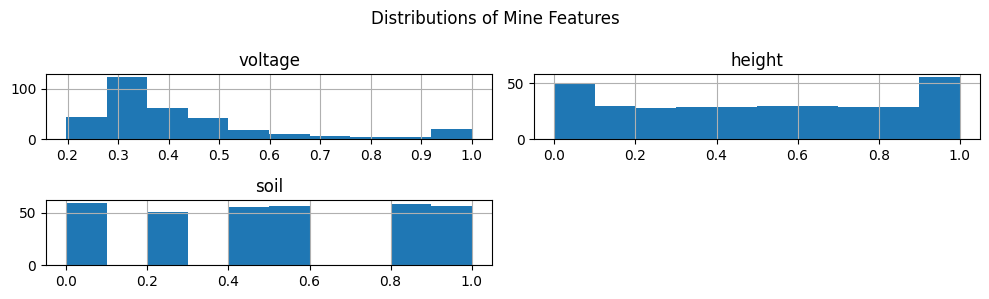

In [11]:
# Q2.1 Load the data and perform EDA

import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file from the data folder.
land_mines = pd.read_csv("data/land_mines.csv")

# First, I want to see how big the dataset is and what the first few rows look like.
print("Data shape:", land_mines.shape)
print("\nFirst five rows:")
display(land_mines.head())

# describe() gives a quick summary of the numerical columns.
print("\nSummary statistics:")
display(land_mines.describe())

# Since mine_type is the label we are trying to predict, I want to see how many
# observations belong to each class.
print("\nMine type counts:")
display(land_mines["mine_type"].value_counts().sort_index())

# Check for missing values before building the model.
print("\nMissing values:")
display(land_mines.isna().sum())

# Looking at the feature averages for each mine type helps me see whether
# the feature values are different across the classes.
print("\nFeature means by mine type:")
display(land_mines.groupby("mine_type")[["voltage", "height", "soil"]].mean())

# Histograms give me a simple look at the distributions of the three features.
land_mines[["voltage", "height", "soil"]].hist(bins=10, figsize=(10, 3))
plt.suptitle("Distributions of Mine Features")
plt.tight_layout()
plt.show()


In [12]:
# Q2.3 Split the data 50/50

from sklearn.model_selection import train_test_split

# The three measurements are the features, and mine_type is the label we want to predict.
X = land_mines[["voltage", "height", "soil"]]
y = land_mines["mine_type"]

# I use half of the data for training and half for testing, as required by the rubric.
# stratify=y keeps the class proportions similar in the two groups.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


Training rows: 169
Test rows: 169


Best k: 2
Best validation accuracy: 0.465


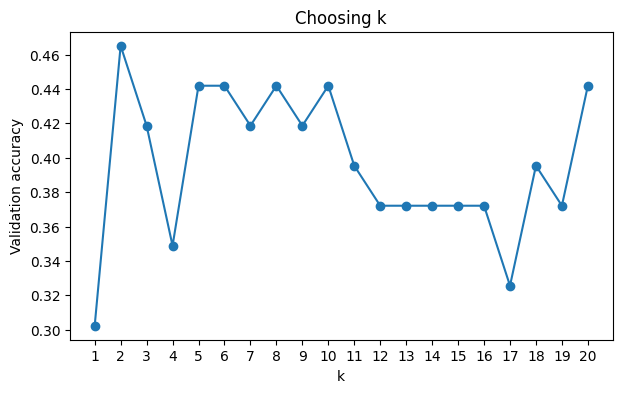

Confusion table: rows = actual, columns = predicted


,1,2,3,4,5
1,26,0,6,3,1
2,0,32,0,3,0
3,12,1,10,6,4
4,9,6,10,8,0
5,11,0,12,8,1


Test accuracy: 0.456

Accuracy by actual mine type:
Mine type 1 : 0.722
Mine type 2 : 0.914
Mine type 3 : 0.303
Mine type 4 : 0.242
Mine type 5 : 0.031


In [13]:
# Q2.4-Q2.8 Build the k-NN model and evaluate it

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# k-NN compares distances between observations. If one feature has much larger
# numbers than another, it could have too much influence on those distances.
# MinMaxScaler puts each feature on a 0-to-1 scale, like the slides show.
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# I keep the test set untouched while choosing k. I split the training data
# again so that I have a small validation set for comparing different k values.
X_fit, X_validate, y_fit, y_validate = train_test_split(
    X_train_scaled, y_train, test_size=0.25, random_state=42, stratify=y_train
)

# Try a range of simple k values and see which one gives the best validation accuracy.
k_values = range(1, 21)
validation_accuracies = []

for k in k_values:
    # This follows the basic create -> fit -> predict workflow from the slides.
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_fit, y_fit)
    predictions = model.predict(X_validate)
    accuracy = accuracy_score(y_validate, predictions)
    validation_accuracies.append(accuracy)

# Pick the k value with the highest validation accuracy.
best_k = list(k_values)[validation_accuracies.index(max(validation_accuracies))]

print("Best k:", best_k)
print("Best validation accuracy:", round(max(validation_accuracies), 3))

# Plotting the validation accuracy makes it easier to see how the choice of k changes performance.
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), validation_accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("Validation accuracy")
plt.title("Choosing k")
plt.xticks(list(k_values))
plt.show()

# Now that k has been chosen, train one final model using all of the training data.
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)

# Use the final model on the test data that was kept separate until this point.
y_pred = model.predict(X_test_scaled)

# Q2.6: The confusion table shows actual classes in the rows and predicted classes in the columns.
labels = [1, 2, 3, 4, 5]
confusion = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion table: rows = actual, columns = predicted")
display(pd.DataFrame(confusion, index=labels, columns=labels))

# Q2.7: Overall test accuracy is the fraction of test observations classified correctly.
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", round(accuracy, 3))

# Looking at each mine type separately shows where the model makes more or fewer mistakes.
print("\nAccuracy by actual mine type:")
for mine_type in labels:
    correct = confusion[mine_type - 1, mine_type - 1]
    total = confusion[mine_type - 1].sum()
    print("Mine type", mine_type, ":", round(correct / total, 3))


### *Reflection on AI assistance
In your own words without generative AI.

The AI assistance helped me make the notebook more organized and check that the model evaluation matched the questions in the rubric. One useful change was keeping the k-NN code close to the workflow shown in the course slides and using MinMaxScaler before calculating distances. I also changed the process for choosing k so that I used a validation set instead of repeatedly checking the final test set. This keeps the test set separate until the final evaluation. I rejected some of the AI's suggestions because they were mostly cosmetic. For example, a color-coded confusion-matrix heatmap and extra plot colors could make the notebook look different, but they would not give me more information about the model. I also rejected decorative formatting because it did not improve the analysis. I verified the final solution by running the notebook from beginning to end and checking that the cells produced the expected tables, plots, confusion matrix, and accuracy results. One remaining concern is that the model's accuracy is not especially high, so I would not use it by itself for a real mine-clearance decision. The model would need to be treated as a supporting tool rather than the final authority for removing the mines.